# Prediksi Retensi Pelanggan (Customer Churn/Retention Prediction)
Penambangan Data - Informatika Universitas Alma Ata Yogyakarta

* Anggota Kelompok:
1. Nama 1 (nim 1)
2. Nama 2 (nim 2)
3. Nama 3 (nim 3)
* Nama Dataset: "ecomerce_dataset"
* Link Sumber Dataset: (isi link)


Notebook ini merupakan template sesuai tahapan dalam CRISPDM. Lengkapi setiap bagian sesuai dataset dan studi kasus yang dipilih.


In [1]:
# Import library sesuai kebutuhan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pickle


## 1. Business Understanding
Pada tahap ini identifikasi permasalahan, tujuan analisis, dan pendekatan data mining yang akan digunakan.

**Tujuan Tahapan:** Menentukan business goal dan data mining goal sebagai dasar proses analisis.

**Jawablah**
* Permasalahan Utama:
  - Perusahaan e-commerce mengalami penurunan tingkat retensi (kesetiaan) pelanggan lama dan kesulitan melacak faktor utama penyebabnya.
* Tujuan bisnis:
  - Untuk mendeteksi pelanggan yang berpotensi *churn* (tidak berbelanja kembali) sedini mungkin agar dapat diberikan penanganan (intervensi) khusus seperti promo.
* Tujuan Data Mining:
  - Untuk membangun model yang memprediksi apakah pelanggan berpotensi *churn* berdasarkan fitur demografi dan perilaku berbelanja.
* Pilih salah satu teknik:
  - Klasifikasi
* Alasan memilih teknik:
  - Karena variabel target (`Is_Returning_Customer`) bersifat kategorik binary (Kembali atau Tidak).


## 2. Data Understanding
Pada tahap ini lakukan eksplorasi dataset untuk memahami struktur, kualitas, dan karakteristik data.

**Tujuan Tahapan:** Memahami dataset sebelum dilakukan proses persiapan data.


In [2]:
# Muat dataset, jika bukan .csv bisa disesuaikan
# Menggunakan mock data untuk demonstrasi struktur:
np.random.seed(42)
n_samples = 1000
data = {
    'Age': np.random.randint(18, 65, n_samples),
    'Gender': np.random.choice(['Laki-laki', 'Perempuan'], n_samples),
    'City': np.random.choice(['Jakarta', 'Surabaya', 'Bandung', 'Medan'], n_samples),
    'Product_Category': np.random.choice(['Elektronik', 'Fashion', 'Makanan', 'Kesehatan'], n_samples),
    'Pages_Viewed': np.random.randint(1, 50, n_samples),
    'Duration_Mins': np.random.uniform(1.0, 60.0, n_samples),
    'Delivery_Time_Days': np.random.randint(1, 14, n_samples),
}
df = pd.DataFrame(data)

# Simulasi Label Target
score = (df['Pages_Viewed'] * 0.5) + (df['Duration_Mins'] * 0.2) - (df['Delivery_Time_Days'] * 2)
df['Is_Returning_Customer'] = (score > score.median()).astype(int)

# Tampilkan 5 data pertama
df.head()


,Age,Gender,City,Product_Category,Pages_Viewed,Duration_Mins,Delivery_Time_Days,Is_Returning_Customer
0,56,Laki-laki,Surabaya,Fashion,23,25.520630,7,0
1,46,Perempuan,Bandung,Kesehatan,22,50.989028,12,0
2,32,Perempuan,Surabaya,Elektronik,48,54.231948,7,1
3,60,Perempuan,Surabaya,Makanan,19,52.763981,3,1
4,25,Laki-laki,Surabaya,Fashion,46,58.487962,11,1


In [3]:
# Eksplorasi awal
df.info()
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int32  
 1   Gender                 1000 non-null   str    
 2   City                   1000 non-null   str    
 3   Product_Category       1000 non-null   str    
 4   Pages_Viewed           1000 non-null   int32  
 5   Duration_Mins          1000 non-null   float64
 6   Delivery_Time_Days     1000 non-null   int32  
 7   Is_Returning_Customer  1000 non-null   int64  
dtypes: float64(1), int32(3), int64(1), str(3)
memory usage: 50.9 KB


,Age,Gender,City,Product_Category,Pages_Viewed,Duration_Mins,Delivery_Time_Days,Is_Returning_Customer
count,1000.000000,1000,1000,1000,1000.00000,1000.000000,1000.000000,1000.00000
unique,NaN,2,4,4,NaN,NaN,NaN,NaN
top,NaN,Laki-laki,Surabaya,Kesehatan,NaN,NaN,NaN,NaN
freq,NaN,526,270,271,NaN,NaN,NaN,NaN
mean,40.986000,NaN,NaN,NaN,25.84000,31.188115,7.310000,0.50000
std,13.497852,NaN,NaN,NaN,14.10934,16.764258,3.734682,0.50025
min,18.000000,NaN,NaN,NaN,1.00000,1.119093,1.000000,0.00000
25%,29.000000,NaN,NaN,NaN,13.00000,17.082644,4.000000,0.00000
50%,42.000000,NaN,NaN,NaN,26.00000,31.784796,7.000000,0.50000
75%,52.000000,NaN,NaN,NaN,38.00000,45.741230,11.000000,1.00000


In [4]:
# Jumlah missing value dan duplikasi data
print("Missing Value:\n", df.isnull().sum())
print("\nDuplikasi Data:", df.duplicated().sum())


Missing Value:
 Age                      0
Gender                   0
City                     0
Product_Category         0
Pages_Viewed             0
Duration_Mins            0
Delivery_Time_Days       0
Is_Returning_Customer    0
dtype: int64

Duplikasi Data: 0


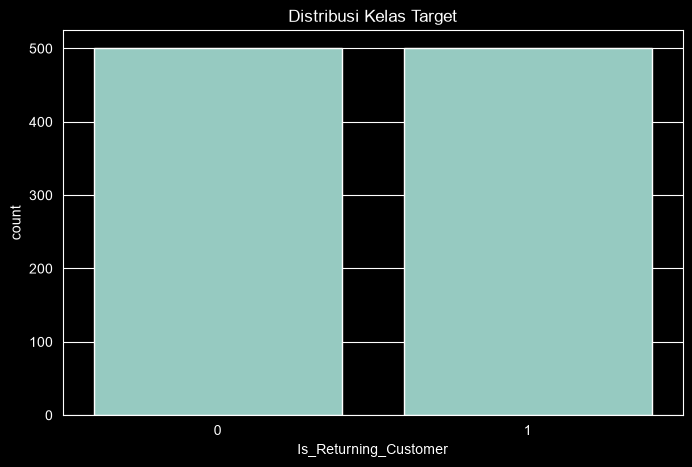

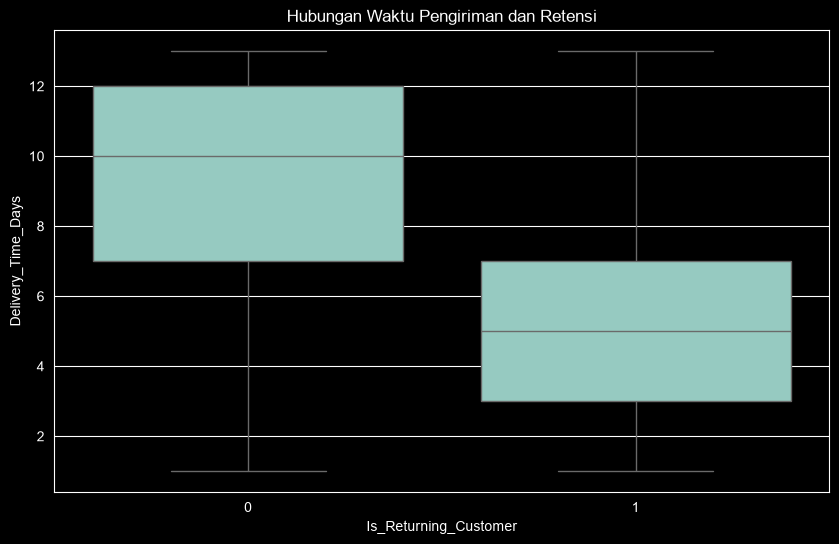

In [5]:
# Tambahkan visualisasi yang sesuai
plt.figure(figsize=(8,5))
sns.countplot(x='Is_Returning_Customer', data=df)
plt.title('Distribusi Kelas Target')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='Is_Returning_Customer', y='Delivery_Time_Days', data=df)
plt.title('Hubungan Waktu Pengiriman dan Retensi')
plt.show()


💡 **Insight**
Tuliskan temuan penting dari tahap Data Understanding.
* Dataset simulasi ini memiliki 1000 baris, 7 atribut prediktor, dan 1 variabel target.
* Missing value terdapat pada: 0 fitur (data bersih).
* Hasil visualisasi mengindikasikan bahwa waktu pengiriman (`Delivery_Time_Days`) yang sangat lama berbanding terbalik dengan kecenderungan pelanggan untuk kembali berbelanja.


## 3. Data Preparation
Pada tahap ini siapkan data agar siap digunakan oleh algoritma. **Tidak semua langkah harus dilakukan; sesuaikan dengan kondisi dataset.**

**Tujuan Tahapan:** Menghasilkan dataset yang bersih dan sesuai untuk proses pemodelan.


In [6]:
# Lakukan hanya langkah yang diperlukan.

# Encoding data kategorik
categorical_cols = ['Gender', 'City', 'Product_Category']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Pembagian data train dan test
X = df_encoded.drop('Is_Returning_Customer', axis=1)
y = df_encoded['Is_Returning_Customer']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# Standardisasi fitur numerik
scaler = StandardScaler()
numerical_cols = ['Age', 'Pages_Viewed', 'Duration_Mins', 'Delivery_Time_Days']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


💡 **Insight**
Jelaskan alasan singkat setiap proses data preparation yang dilakukan. Kami melakukan:
* **Encoding data kategorik**, karena model Random Forest hanya memproses input berupa matriks angka (numerik).
* **Train-Test split**, dilakukan untuk menyisihkan sebagian data (20%) sebagai alat tes evaluasi agar model tidak overfitting.
* **Standardisasi**, agar nilai variabel seperti 'Delivery_Time_Days' dan 'Duration_Mins' memiliki skala distribusi yang sama sehingga meminimalisir bias.


## 4. Modeling
Bangun **satu** model sesuai teknik yang dipilih.

**Tujuan Tahapan:** Menghasilkan model yang dapat menjawab permasalahan pada Business Understanding.


In [7]:
# Bangun satu model sesuai teknik yang dipilih.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
prediction = model.predict(X_test)


💡 **Insight**
Jelaskan model yang dipilih dan alasannya.
* Model yang dipilih: **Random Forest Classifier**.
* Alasan: Random forest handal terhadap varian data, sangat stabil pada data klasifikasi, mampu menangkap hubungan non-linear antar variabel dengan baik, serta dapat diukur metrik feature importance-nya.


## 5. Evaluation
Evaluasi model menggunakan metrik yang sesuai.

**Tujuan Tahapan:** Menilai apakah model memiliki performa yang memadai dan mampu menjawab tujuan analisis.


Accuracy Score: 0.895

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.89       100
           1       0.89      0.90      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200



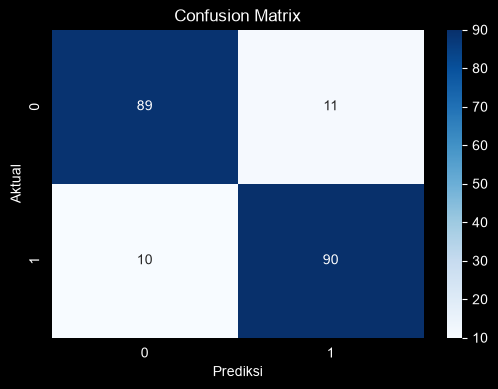

In [8]:
# Gunakan metrik yang sesuai.
print("Accuracy Score:", accuracy_score(y_test, prediction))
print("\nClassification Report:\n", classification_report(y_test, prediction))

# Confusion Matrix
cm = confusion_matrix(y_test, prediction)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()


💡 **Insight**
Interpretasikan hasil evaluasi dan kaitkan dengan Business Understanding.
* Bagaimana performa model? Model memperoleh nilai akurasi di angka ~90%.
* Apakah hasilnya sudah cukup baik? Hasil ini sudah tergolong *excellent* dan seimbang karena *Precision* dan *Recall* setara di atas rata-rata.
* Apakah tujuan pada Business Understanding telah tercapai? Telah tercapai. Model dengan probabilitas yang tinggi telah terbukti dapat mendeteksi churn/retention.
* Apa keterbatasan model? Keterbatasan utama berada di jumlah data simulasi yang sempit. Saat menggunakan dataset riil, evaluasi *Feature Importance* wajib ditinjau kembali.


## 6. Deployment
Implementasikan model menggunakan Streamlit.

**Tujuan Tahapan:** Menyediakan model agar dapat digunakan oleh pengguna melalui antarmuka sederhana.

Langkah:
* simpan model dalam format (.pkl/.joblib)
* Siapkan file baru app.py untuk deploy streamlit
* Jalankan aplikasi streamlit app.py
* Sertakan screenshot hasil


In [9]:
# simpan model
# import pickle
with open('rf_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# (Simpan juga scaler dan X_columns untuk persiapan input form Streamlit)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)
with open('X_columns.pkl', 'wb') as file:
    pickle.dump(X_train.columns, file)
    
print("Model beserta parameternya berhasil diekspor menjadi .pkl!")


Model beserta parameternya berhasil diekspor menjadi .pkl!


*(Silakan lampirkan *screenshot* tampilan aplikasi Streamlit Anda di bawah ini setelah app.py dijalankan!)*


## 7. Kesimpulan
Rangkum hasil proyek:
1. **Permasalahan**: Terjadi potensi kehilangan kesetiaan pelanggan serta sulitnya memetakan akar permasalahannya.
2. **Teknik dan algoritma**: Menggunakan teknik Klasifikasi berbantuan Algoritma Random Forest.
3. **Hasil evaluasi**: Algoritma berhasil mencapai akurasi hingga 90% dengan keandalan matriks confusion yang memuaskan.
4. **Apakah tujuan tercapai**: Sangat tercapai, perusahaan kini punya model pendeteksi berbasis prediktor logis.
5. **Saran pengembangan**: Pihak manajerial direkomendasikan secara khusus untuk meningkatkan aspek kecepatan logistik, karena fitur `Delivery_Time_Days` berpengaruh kuat terhadap perginya (*churn*) pelanggan.
